# LAB | Imbalanced

**Load the data**

In this challenge, we will be working with Credit Card Fraud dataset.

https://raw.githubusercontent.com/data-bootcamp-v4/data/main/card_transdata.csv

Metadata

- **distance_from_home:** the distance from home where the transaction happened.
- **distance_from_last_transaction:** the distance from last transaction happened.
- **ratio_to_median_purchase_price:** Ratio of purchased price transaction to median purchase price.
- **repeat_retailer:** Is the transaction happened from same retailer.
- **used_chip:** Is the transaction through chip (credit card).
- **used_pin_number:** Is the transaction happened by using PIN number.
- **online_order:** Is the transaction an online order.
- **fraud:** Is the transaction fraudulent. **0=legit** -  **1=fraud**


In [3]:
#Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [4]:
fraud = pd.read_csv("https://raw.githubusercontent.com/data-bootcamp-v4/data/main/card_transdata.csv")
fraud.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


**Steps:**

- **1.** What is the distribution of our target variable? Can we say we're dealing with an imbalanced dataset?
- **2.** Train a LogisticRegression.
- **3.** Evaluate your model. Take in consideration class importance, and evaluate it by selection the correct metric.
- **4.** Run **Oversample** in order to balance our target variable and repeat the steps above, now with balanced data. Does it improve the performance of our model? 
- **5.** Now, run **Undersample** in order to balance our target variable and repeat the steps above (1-3), now with balanced data. Does it improve the performance of our model?
- **6.** Finally, run **SMOTE** in order to balance our target variable and repeat the steps above (1-3), now with balanced data. Does it improve the performance of our model? 

fraud
0.0    0.912597
1.0    0.087403
Name: proportion, dtype: float64

--- Original ---
[[271936   1843]
 [ 10432  15789]]
              precision    recall  f1-score   support

         0.0      0.963     0.993     0.978    273779
         1.0      0.895     0.602     0.720     26221

    accuracy                          0.959    300000
   macro avg      0.929     0.798     0.849    300000
weighted avg      0.957     0.959     0.955    300000


--- Oversampled ---
[[255517  18262]
 [  1357  24864]]
              precision    recall  f1-score   support

         0.0      0.995     0.933     0.963    273779
         1.0      0.577     0.948     0.717     26221

    accuracy                          0.935    300000
   macro avg      0.786     0.941     0.840    300000
weighted avg      0.958     0.935     0.942    300000


--- Undersampled ---
[[255528  18251]
 [  1328  24893]]
              precision    recall  f1-score   support

         0.0      0.995     0.933     0.963    273779


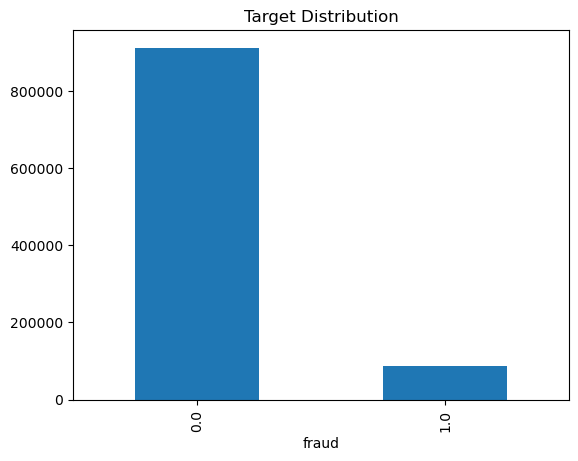

In [5]:
# 1. Load and inspect target distribution
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

df = pd.read_csv("https://raw.githubusercontent.com/data-bootcamp-v4/data/main/card_transdata.csv")
print(df["fraud"].value_counts(normalize=True))  # Distribution
df["fraud"].value_counts().plot(kind="bar", title="Target Distribution")

# 2. Split data
X = df.drop("fraud", axis=1)
y = df["fraud"]
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# 3. Train and evaluate base LogisticRegression
def train_and_evaluate(X_tr, y_tr, X_te, y_te, label="Original"):
    model = LogisticRegression(max_iter=1000)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    print(f"\n--- {label} ---")
    print(confusion_matrix(y_te, y_pred))
    print(classification_report(y_te, y_pred, digits=3))

train_and_evaluate(X_train, y_train, X_test, y_test, label="Original")

# 4. Oversample
ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X_train, y_train)
train_and_evaluate(X_ros, y_ros, X_test, y_test, label="Oversampled")

# 5. Undersample
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_train, y_train)
train_and_evaluate(X_rus, y_rus, X_test, y_test, label="Undersampled")

# 6. SMOTE
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)
train_and_evaluate(X_smote, y_smote, X_test, y_test, label="SMOTE")